# Random Log 10

Starting UNWEIGHTED FINITE parallel ensemble: 10 realizations, 2000 cells each.
Perturbing central cell vertices by Δa = 0.001...
--------------------------------------------------


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out of  10 | elapsed:   12.8s remaining:   29.8s
[Parallel(n_jobs=-1)]: Done   5 out of  10 | elapsed:   12.8s remaining:   12.8s
[Parallel(n_jobs=-1)]: Done   7 out of  10 | elapsed:   12.9s remaining:    5.5s
[Parallel(n_jobs=-1)]: Done  10 out of  10 | elapsed:   13.0s finished


Ensemble generation complete.
Exported '.npy' files successfully.
Decay constant (slope): -0.55310
--------------------------------------------------


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


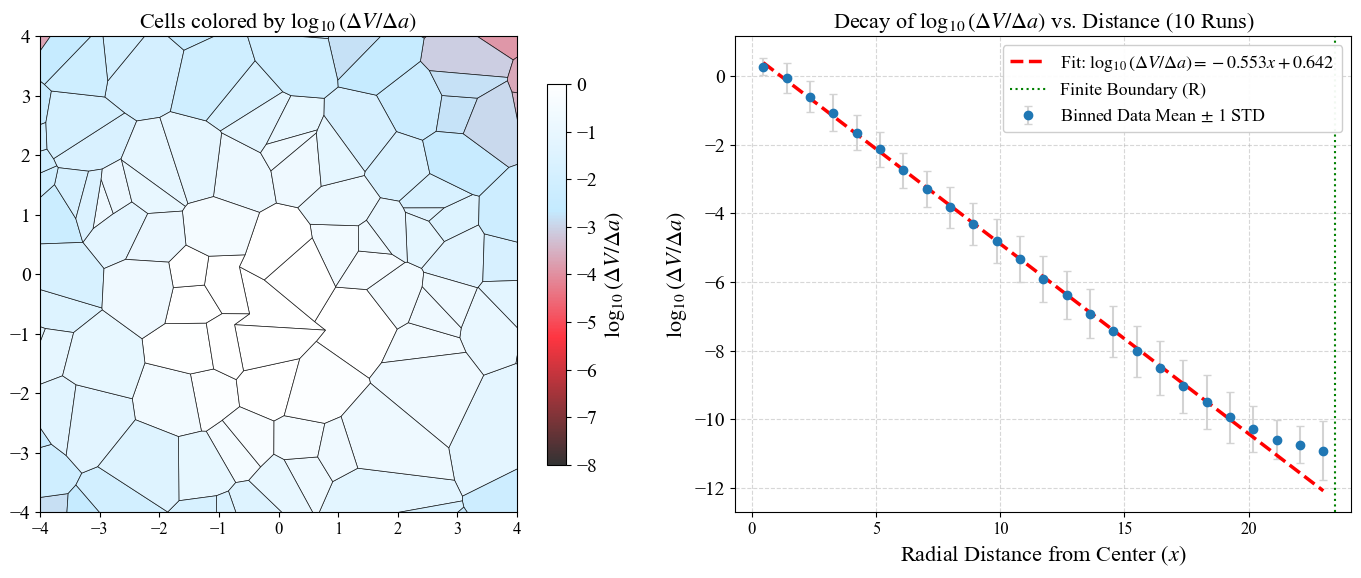

In [1]:
import sys
import time
import copy
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from scipy.spatial import Voronoi
from matplotlib.collections import PolyCollection
from decimal import Decimal, getcontext
from joblib import Parallel, delayed
from scipy.stats import linregress

# ==========================================
# 1) Setup & Publication Styling
# ==========================================
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif', 'serif'],
    'mathtext.fontset': 'stix', 
    'font.size': 14,
    'axes.labelsize': 16,
    'axes.titlesize': 16,
    'xtick.labelsize': 12,
    'ytick.labelsize': 14,
    'legend.fontsize': 13,
    'figure.titlesize': 18
})

# ==========================================
# 2) Parallel Worker Function
# ==========================================
def run_realization(realization_idx, num_cells_target, d_target_str, steps, R_str, area_per_cell_str):
    """
    Executes a single realization of the Voronoi optimization within a FINITE circular boundary.
    Disturbs the central cell vertices and calculates Delta V / Delta a after optimization.
    """
    start_time = time.time()
    
    # 1. Set precision locally inside the worker process
    getcontext().prec = 64
    
    # 2. Reconstruct exact Decimals
    d_target = Decimal(d_target_str)
    R = Decimal(R_str)
    area_per_cell = Decimal(area_per_cell_str)
    
    # 3. Create an independent random generator for this specific thread
    rng = np.random.default_rng(realization_idx)

    # --- Generate Random Points (Circle + Annulus Padding) ---
    padding = Decimal('2.0') * d_target
    R_float = float(R)
    pad_float = float(padding)
    R_outer = R_float + pad_float

    # Core points inside the target radius
    r_in = R_float * np.sqrt(rng.uniform(0, 1, num_cells_target))
    theta_in = rng.uniform(0, 2*np.pi, num_cells_target)
    pts_in = np.column_stack((r_in * np.cos(theta_in), r_in * np.sin(theta_in)))

    # Padding points in a surrounding ring (annulus) to bound the edges
    area_annulus = np.pi * (R_outer**2 - R_float**2)
    num_pad = int(area_annulus / float(area_per_cell)) + 50
    r_out = np.sqrt(rng.uniform(R_float**2, R_outer**2, num_pad))
    theta_out = rng.uniform(0, 2*np.pi, num_pad)
    pts_pad = np.column_stack((r_out * np.cos(theta_out), r_out * np.sin(theta_out)))

    pts_raw = np.vstack((pts_in, pts_pad))
    pts = np.array([[Decimal(str(x)), Decimal(str(y))] for x, y in pts_raw], dtype=object)

    vor = Voronoi(pts_raw)
    XYv_strained = np.array([[Decimal(str(v[0])), Decimal(str(v[1]))] for v in vor.vertices], dtype=object)
    seeds_unstrained = copy.deepcopy(pts)

    # --- Filter and Format Cells ---
    cells = []
    edge_to_cells = {}

    for i, region_idx in enumerate(vor.point_region):
        region = vor.regions[region_idx]
        seed_pos_raw = pts[i]
        if -1 not in region and len(region) >= 3:
            # Finite condition: keep only cells whose initial seeds fall inside the circle
            dist_sq = seed_pos_raw[0]**2 + seed_pos_raw[1]**2
            if dist_sq <= R**2:
                cell_verts = region
                target_seeds_val = seeds_unstrained[i] 
                
                current_verts = XYv_strained[cell_verts]
                mean_x = sum(v[0] for v in current_verts) / Decimal(len(current_verts))
                mean_y = sum(v[1] for v in current_verts) / Decimal(len(current_verts))
                
                cells.append({
                    'verts': cell_verts, 
                    'target_seeds': target_seeds_val, 
                    'geometric_centroid': np.array([mean_x, mean_y], dtype=object)
                })
                
                for u, v in zip(cell_verts, cell_verts[1:] + cell_verts[:1]):
                    key = tuple(sorted((u, v)))
                    edge_to_cells.setdefault(key, []).append(len(cells) - 1)

    Nc = len(cells)

    # --- Identify Central Cell and Perturb its Vertices ---
    # Find the cell closest to the origin (0, 0)
    dist_sqs = [float(c['geometric_centroid'][0]**2 + c['geometric_centroid'][1]**2) for c in cells]
    center_idx = np.argmin(dist_sqs)
    center_verts = cells[center_idx]['verts']

    delta_a = 0.001
    delta_a_dec = Decimal(str(delta_a))

    # Initialize tracking array for vertex shifts to exaggerate visually later
    vertex_shifts = np.zeros((len(XYv_strained), 2), dtype=object)
    for i in range(len(XYv_strained)):
        vertex_shifts[i] = [Decimal('0'), Decimal('0')]

    # Apply random perturbations to the central cell's vertices
    for v_idx in center_verts:
        theta = rng.uniform(0, 2*np.pi)
        dx = delta_a_dec * Decimal(str(np.cos(theta)))
        dy = delta_a_dec * Decimal(str(np.sin(theta)))
        XYv_strained[v_idx][0] += dx
        XYv_strained[v_idx][1] += dy
        vertex_shifts[v_idx][0] = dx
        vertex_shifts[v_idx][1] = dy

    # --- Optimization / Reflective Math ---
    def reflect_point_over_line(p, a, b):
        ab0 = b[0] - a[0]
        ab1 = b[1] - a[1]
        denom = ab0*ab0 + ab1*ab1
        
        if denom < Decimal('1e-31'): 
            return p
        
        p_minus_a0 = p[0] - a[0]
        p_minus_a1 = p[1] - a[1]
        t = (p_minus_a0*ab0 + p_minus_a1*ab1) / denom
        
        r0 = Decimal('2.0') * (a[0] + t * ab0) - p[0]
        r1 = Decimal('2.0') * (a[1] + t * ab1) - p[1]
        return np.array([r0, r1], dtype=object)

    final_seeds = np.array([c['geometric_centroid'] for c in cells], dtype=object)

    # Run for the specified number of steps
    for step in range(steps):
        new_seeds = np.empty_like(final_seeds)
        
        for i in range(Nc):
            reflections = []
            for u, v in zip(cells[i]['verts'], cells[i]['verts'][1:] + cells[i]['verts'][:1]):
                key = tuple(sorted((u, v)))
                cs = edge_to_cells.get(key, [])
                if len(cs) == 2:
                    j = cs[0] if cs[1] == i else cs[1]
                    reflections.append(reflect_point_over_line(final_seeds[j], XYv_strained[u], XYv_strained[v]))
            
            # Unweighted update (simple average)
            if reflections:
                mean_rx = sum(r[0] for r in reflections) / Decimal(len(reflections))
                mean_ry = sum(r[1] for r in reflections) / Decimal(len(reflections))
                new_seeds[i] = np.array([mean_rx, mean_ry], dtype=object)
            else:
                new_seeds[i] = final_seeds[i]
                
        final_seeds = new_seeds

    # --- Calculate Delta V / Delta a (Non-Voronoiness) ---
    delta_V = np.zeros(Nc, dtype=float)
    
    for i in range(Nc):
        ratios = []
        for u, v in zip(cells[i]['verts'], cells[i]['verts'][1:] + cells[i]['verts'][:1]):
            key = tuple(sorted((u, v)))
            cs = edge_to_cells.get(key, [])
            if len(cs) == 2:
                j = cs[0] if cs[1] == i else cs[1]
                r = reflect_point_over_line(final_seeds[j], XYv_strained[u], XYv_strained[v])
                
                # denom = || reflected_neighbor - final_neighbor ||
                denom_sq = (r[0] - final_seeds[j][0])**2 + (r[1] - final_seeds[j][1])**2
                # num = || reflected_neighbor - final_self ||
                num_sq = (r[0] - final_seeds[i][0])**2 + (r[1] - final_seeds[i][1])**2
                
                if denom_sq > Decimal('1e-32'):
                    ratios.append(float(num_sq.sqrt() / denom_sq.sqrt()))
        
        if ratios:
            delta_V[i] = np.mean(ratios)
        else:
            delta_V[i] = np.nan

    # Calculate log10(Delta V / Delta a)
    valid_mask = ~np.isnan(delta_V)
    log_delta_v_ratio = np.full(Nc, np.nan, dtype=float)
    log_delta_v_ratio[valid_mask] = np.log10(np.clip(delta_V[valid_mask] / delta_a, 1e-32, None))

    # Calculate distance from the central perturbed seed
    center_seed = final_seeds[center_idx]
    distances = np.array([float(((s[0]-center_seed[0])**2 + (s[1]-center_seed[1])**2).sqrt()) for s in final_seeds])

    # --- Prepare Visual Data ONLY for realization 0 to save processing time ---
    plot_data = None
    if realization_idx == 0:
        # Exaggerate the perturbation visually so it's visible on the plot
        visual_exaggeration = Decimal('200.0') 
        plot_vertices = np.empty_like(XYv_strained)
        for i in range(len(XYv_strained)):
            plot_vertices[i, 0] = XYv_strained[i, 0] + vertex_shifts[i, 0] * visual_exaggeration
            plot_vertices[i, 1] = XYv_strained[i, 1] + vertex_shifts[i, 1] * visual_exaggeration
            
        poly_verts = []
        for c in cells:
            poly = np.array([[float(plot_vertices[v, 0]), float(plot_vertices[v, 1])] for v in c['verts']])
            poly_verts.append(poly)
            
        plot_data = (poly_verts, log_delta_v_ratio.copy())

    end_time = time.time()
    exec_time = end_time - start_time

    return distances, log_delta_v_ratio, exec_time, plot_data

# ==========================================
# 3) Main Execution Block
# ==========================================
if __name__ == '__main__':
    # Set precision for the main thread
    getcontext().prec = 64

    # Setup Parameters
    num_realizations = 10         
    d_target = Decimal('1.0')
    
    # Robust handling for Jupyter Notebook execution vs Terminal execution
    num_cells_target = 2000  # Default value
    if len(sys.argv) > 1:
        try:
            num_cells_target = int(sys.argv[1])
        except ValueError:
            pass  # If it's a Jupyter hidden argument like '-f', ignore it and keep the default
            
    steps = 200 

    # Calculate required Radius based on target number of cells
    area_per_cell = Decimal(str(np.sqrt(3))) / Decimal('2.0')
    total_area = Decimal(num_cells_target) * area_per_cell
    pi_val = Decimal(str(np.pi))
    R = (total_area / pi_val).sqrt()
    R_float = float(R)

    print(f"Starting UNWEIGHTED FINITE parallel ensemble: {num_realizations} realizations, {num_cells_target} cells each.")
    print("Perturbing central cell vertices by Δa = 0.001...")
    print("-" * 50)

    # --- Execute Parallel Jobs ---
    results = Parallel(n_jobs=-1, verbose=10)(
        delayed(run_realization)(i, num_cells_target, str(d_target), steps, str(R), str(area_per_cell))
        for i in range(num_realizations)
    )

    # --- Aggregate Results ---
    all_distances = []
    all_log_ratios = []
    all_exec_times = []
    final_plot_data = None

    for res in results:
        all_distances.append(res[0])
        all_log_ratios.append(res[1])
        all_exec_times.append(res[2])
        if res[3] is not None:
            final_plot_data = res[3]

    # Combine spatial data across all runs
    all_distances = np.concatenate(all_distances)
    all_log_ratios = np.concatenate(all_log_ratios)

    # Filter out NaNs
    valid_idx = ~np.isnan(all_log_ratios)
    all_distances = all_distances[valid_idx]
    all_log_ratios = all_log_ratios[valid_idx]

    # --- Calculate spatial statistics vs Distance from Center ---
    num_bins = 25
    bins = np.linspace(0, R_float, num_bins + 1)
    bin_centers = 0.5 * (bins[:-1] + bins[1:])
    
    spatial_mean_log = np.zeros(num_bins)
    spatial_std_log = np.zeros(num_bins)
    
    bin_indices = np.digitize(all_distances, bins)
    
    for b in range(1, num_bins + 1):
        mask = (bin_indices == b)
        if np.any(mask):
            spatial_mean_log[b-1] = np.mean(all_log_ratios[mask])
            spatial_std_log[b-1] = np.std(all_log_ratios[mask])
        else:
            spatial_mean_log[b-1] = np.nan
            spatial_std_log[b-1] = np.nan

    # --- Linear Fit on Valid Bins ---
    fit_mask = ~np.isnan(spatial_mean_log) & (bin_centers < R_float * 0.9) # Avoid boundary artifacts
    slope, intercept, r_value, p_value, std_err = linregress(bin_centers[fit_mask], spatial_mean_log[fit_mask])
    fit_line = slope * bin_centers + intercept
    
    fit_equation = fr"Fit: $\log_{{10}}(\Delta V / \Delta a) = {slope:.3f}x {intercept:+.3f}$"

    # ==============================================
    # 4) Export Data to .npy
    # ==============================================
    avg_time_per_realization = np.mean(all_exec_times)
    np.save('average_time.npy', np.array([avg_time_per_realization]))
    
    # Save log Delta V/Delta a vs space (Row 0: Bin Centers, Row 1: Means, Row 2: STDs)
    space_data = np.vstack((bin_centers, spatial_mean_log, spatial_std_log))
    np.save('log_deltaV_vs_distance.npy', space_data)

    print("Ensemble generation complete.")
    print("Exported '.npy' files successfully.")
    print(f"Decay constant (slope): {slope:.5f}")
    print("-" * 50)

    # ==============================================
    # 5) Visualization (Side-by-Side Plots)
    # ==============================================
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
    
    # --- Plot 1 (Left): Geometry with Custom Colormap ---
    if final_plot_data is not None:
        poly_verts, log_ratios_0 = final_plot_data
        
        cmap_viridis = mcolors.LinearSegmentedColormap.from_list(
            "PuBuRed",
            ["#000000","#FF0211","#B5E5FF","#FFFFFF"]
        )
        
        pc = PolyCollection(poly_verts, cmap=cmap_viridis, alpha=0.8, edgecolor='black', linewidth=0.5)
        pc.set_array(log_ratios_0)
        pc.set_clim(vmin=-8, vmax=0)
        ax1.add_collection(pc)
        
        # Center view around the origin (since finite circle is centered at 0)
        ax1.set_xlim(-4, 4)
        ax1.set_ylim(-4, 4)
        ax1.set_aspect('equal', adjustable='box')
        ax1.set_title(r'Cells colored by $\log_{10}(\Delta V / \Delta a)$')
        
        cbar = fig.colorbar(pc, ax=ax1, shrink=0.8)
        cbar.set_label(r'$\log_{10}(\Delta V / \Delta a)$')

    # --- Plot 2 (Right): Decay vs Distance ---
    # Raw string applied here to fix the \p SyntaxWarning
    ax2.errorbar(bin_centers, spatial_mean_log, yerr=spatial_std_log, fmt='o', markersize=6, 
                 color='tab:blue', ecolor='lightgray', capsize=3, elinewidth=1.5, label=r'Binned Data Mean $\pm$ 1 STD')

    ax2.plot(bin_centers, fit_line, 'r--', linewidth=2.5, label=fit_equation)
    ax2.axvline(R_float, color='green', linestyle=':', label='Finite Boundary (R)')
    
    ax2.set_title(f"Decay of $\\log_{{10}}(\\Delta V / \\Delta a)$ vs. Distance ({num_realizations} Runs)")
    ax2.set_xlabel("Radial Distance from Center ($x$)")
    ax2.set_ylabel(r"$\log_{{10}}(\Delta V / \Delta a)$")
    
    ax2.legend(loc='upper right', framealpha=0.95)
    ax2.grid(True, which="both", ls="--", alpha=0.5)
    
    plt.tight_layout()
    plt.savefig('combined_plots.png', dpi=300, bbox_inches='tight')
    plt.savefig('combined_plots.eps', format='eps', bbox_inches='tight')
    plt.show()

# Together

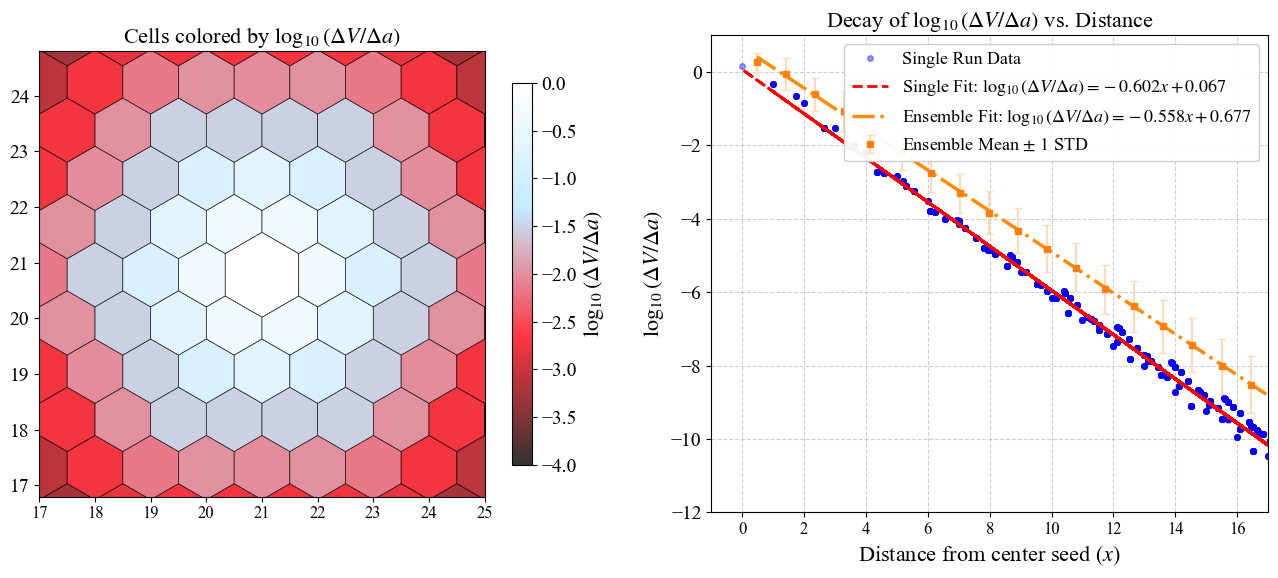

Decay constant (Single Run slope): -0.6017846790594292
Decay constant (Ensemble slope): -0.5581767890064712


In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from scipy.spatial import Voronoi
from scipy.spatial import voronoi_plot_2d
from matplotlib.patches import Polygon
from matplotlib.collections import PatchCollection
from scipy.stats import linregress

# ==========================================
# 1) Setup & Publication Styling
# ==========================================
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif', 'serif'],
    'mathtext.fontset': 'stix', 
    'font.size': 14,
    'axes.labelsize': 16,
    'axes.titlesize': 16,
    'xtick.labelsize': 12,
    'ytick.labelsize': 14,
    'legend.fontsize': 13,
    'figure.titlesize': 18
})

# ----------------------------
# Geometry helpers
# ----------------------------

def make_triangular_lattice_squareish(N_target=None, a=1.0, prefer_more=True):
    root3 = np.sqrt(3.0)
    if N_target is None:
        N_target = 1200

    ny_est = int(max(1, round(np.sqrt((2.0 / root3) * N_target))))
    candidates = []
    for ny in range(max(1, ny_est - 200), ny_est + 201):
        nx = max(1, int(round((root3 / 2.0) * ny)))
        N = nx * ny
        if prefer_more and N < N_target:
            nx2 = int(np.ceil(N_target / ny))
            nx2 = max(nx2, 1)
            N2 = nx2 * ny
            nx, N = nx2, N2
        elif (not prefer_more) and N > N_target:
            nx2 = int(np.floor(N_target / ny))
            nx2 = max(nx2, 1)
            N2 = nx2 * ny
            nx, N = nx2, N2

        if N <= 0:
            continue

        Lx = nx * a
        Ly = ny * (root3 / 2.0) * a
        aspect = max(Lx, Ly) / min(Lx, Ly)
        cost = (aspect - 1.0)**2 + 1e-6 * abs(N - N_target)
        candidates.append((cost, nx, ny, N, Lx, Ly))

    if not candidates:
        raise RuntimeError("Could not find suitable (nx, ny).")

    _, nx, ny, N, Lx, Ly = min(candidates, key=lambda t: t[0])

    pts = np.zeros((N, 2), float)
    idx = 0
    for j in range(ny):
        y = j * (root3 / 2.0) * a
        xoff = 0.5 * a if (j % 2 == 1) else 0.0
        for i in range(nx):
            x = i * a + xoff
            pts[idx] = (x, y)
            idx += 1

    assert idx == N
    return pts, Lx, Ly, nx, ny, N


def non_voronoiness_per_seed(
    central_seed_neighbors, central_seed_vertices, vertices_coords,
    final_coords, N_central, eps=1e-12
):
    out = np.full(N_central, np.nan, dtype=float)
    for n in range(N_central):
        ratios = []
        for (rv, m) in zip(central_seed_vertices[n], central_seed_neighbors[n]):
            if len(rv) == 2 and rv[0] >= 0 and rv[1] >= 0:
                p0 = vertices_coords[rv[0]]
                p1 = vertices_coords[rv[1]]
                mf = final_coords[m]
                nf = final_coords[n]
                r = reflect_point_across_line(p0, p1, mf)
                denom = np.linalg.norm(r - mf)
                num = np.linalg.norm(r - nf)
                ratios.append(num / denom)
        if ratios:
            out[n] = float(np.mean(ratios))
    return out


def reflect_point_across_line(p0, p1, p):
    p0 = np.asarray(p0, float)
    p1 = np.asarray(p1, float)
    p  = np.asarray(p,  float)
    v = p1 - p0
    denom = v @ v
    if denom == 0:
        raise ValueError("p0 and p1 must be distinct to define a line.")
    t = ((p - p0) @ v) / denom       
    f = p0 + t * v                   
    return 2 * f - p                  


def polygon_centroid(pts):
    if len(pts) == 0:
        return np.array([np.nan, np.nan], float)
    return np.mean(pts, axis=0)


# ----------------------------
# Periodic point set
# ----------------------------
def build_periodic_images(central_coords, Lx, Ly):
    N = central_coords.shape[0]
    mx_left  = central_coords[:, 0] >  Lx / 2
    mx_right = central_coords[:, 0] <  Lx / 2
    my_down  = central_coords[:, 1] >  Ly / 2
    my_up    = central_coords[:, 1] <  Ly / 2

    blocks = [central_coords]
    block_ids = [np.arange(N)]
    shifts = [np.zeros_like(central_coords)]

    left_idx  = np.where(mx_left)[0]
    right_idx = np.where(mx_right)[0]
    blocks += [central_coords[left_idx]  + np.array([-Lx, 0.0]),
               central_coords[right_idx] + np.array([+Lx, 0.0])]
    block_ids += [left_idx, right_idx]
    shifts += [np.tile([-Lx, 0.0], (len(left_idx), 1)),
               np.tile([+Lx, 0.0], (len(right_idx), 1))]

    down_idx = np.where(my_down)[0]
    up_idx   = np.where(my_up)[0]
    blocks += [central_coords[down_idx] + np.array([0.0, -Ly]),
               central_coords[up_idx]   + np.array([0.0, +Ly])]
    block_ids += [down_idx, up_idx]
    shifts += [np.tile([0.0, -Ly], (len(down_idx), 1)),
               np.tile([0.0, +Ly], (len(up_idx), 1))]

    ld_idx = np.where(mx_left  & my_down)[0]
    lu_idx = np.where(mx_left  & my_up)[0]
    rd_idx = np.where(mx_right & my_down)[0]
    ru_idx = np.where(mx_right & my_up)[0]
    blocks += [central_coords[ld_idx] + np.array([-Lx, -Ly]),
               central_coords[lu_idx] + np.array([-Lx, +Ly]),
               central_coords[rd_idx] + np.array([+Lx, -Ly]),
               central_coords[ru_idx] + np.array([+Lx, +Ly])]
    block_ids += [ld_idx, lu_idx, rd_idx, ru_idx]
    shifts += [np.tile([-Lx, -Ly], (len(ld_idx), 1)),
               np.tile([-Lx, +Ly], (len(lu_idx), 1)),
               np.tile([+Lx, -Ly], (len(rd_idx), 1)),
               np.tile([+Lx, +Ly], (len(ru_idx), 1))]

    extended_seed_coords = np.vstack(blocks)
    extended_central_indices = np.concatenate(block_ids)
    extended_central_shifts  = np.vstack(shifts)

    return extended_seed_coords, extended_central_indices, extended_central_shifts


# ----------------------------
# Voronoi graph over central seeds
# ----------------------------
def build_central_graph(vor, N_central):
    ridge_points   = vor.ridge_points
    ridge_vertices = vor.ridge_vertices

    central_ridge_indices = [[] for _ in range(N_central)]
    central_seed_neighbors = [[] for _ in range(N_central)]
    central_seed_vertices = [[] for _ in range(N_central)]

    for ridx, (i, j) in enumerate(ridge_points):
        if i < N_central:
            central_ridge_indices[i].append(ridx)
            central_seed_neighbors[i].append(j)
            central_seed_vertices[i].append(ridge_vertices[ridx])
        if j < N_central:
            central_ridge_indices[j].append(ridx)
            central_seed_neighbors[j].append(i)
            central_seed_vertices[j].append(ridge_vertices[ridx])

    return central_ridge_indices, central_seed_neighbors, central_seed_vertices


def cell_centers_from_ridges(central_seed_vertices, vertices_coords, fallback_coords=None):
    centers = []
    for n, ridge_vs in enumerate(central_seed_vertices):
        finite_lists = [rv for rv in ridge_vs if (len(rv) == 2 and rv[0] >= 0 and rv[1] >= 0)]
        unique_idx = np.unique(np.array(finite_lists).ravel()) if finite_lists else np.array([], dtype=int)
        ctr = polygon_centroid(vertices_coords[unique_idx]) if len(unique_idx) else np.array([np.nan, np.nan])
        if (np.isnan(ctr).any()) and fallback_coords is not None:
            ctr = fallback_coords[n]
        centers.append(ctr)
    return np.vstack(centers)


# ----------------------------
# One relaxation-like step via reflections
# ----------------------------
def next_positions(central_seed_neighbors, central_seed_vertices, vertices_coords,
                   initial_coords, N_central, extended_central_indices, extended_central_shifts):
    N_ext = len(extended_central_indices)
    nxt = np.zeros((N_ext, 2), float)

    for n in range(N_central):
        reflecteds = []
        for (rv, m) in zip(central_seed_vertices[n], central_seed_neighbors[n]):
            if len(rv) == 2 and rv[0] >= 0 and rv[1] >= 0:
                p0 = vertices_coords[rv[0]]
                p1 = vertices_coords[rv[1]]
                p2 = initial_coords[m]
                reflecteds.append(reflect_point_across_line(p0, p1, p2))
        if reflecteds:
            nxt[n] = np.mean(reflecteds, axis=0)
        else:
            nxt[n] = initial_coords[n]  

    for m in range(N_central, N_ext):
        n = extended_central_indices[m]
        nxt[m] = nxt[n] + extended_central_shifts[m]

    return nxt


a = 0.01 
scale = 1
n_target = 2000
n_steps = 200
delta = a*scale*2/np.sqrt(3)

tri_pts, Lx, Ly, nx, ny, N_central_seeds = make_triangular_lattice_squareish(
    N_target=n_target,  
    a=scale,          
    prefer_more=True  
)

central_seed_coords = tri_pts

extended_seed_coords, extended_central_indices, extended_central_shifts = \
    build_periodic_images(central_seed_coords, Lx, Ly)
N_extended_seeds = extended_seed_coords.shape[0]

vor = Voronoi(extended_seed_coords)

(central_ridge_indices,
    central_seed_neighbors,
    central_seed_vertices) = build_central_graph(vor, N_central_seeds)

vertices_coords = vor.vertices
initial_coords = np.zeros((N_extended_seeds, 2), float)
initial_coords[:N_central_seeds] = cell_centers_from_ridges(
    central_seed_vertices, vertices_coords, fallback_coords=central_seed_coords
)

box_center = np.array([Lx/2, Ly/2], dtype=float)
central_seed_idx = np.argmin(np.linalg.norm(central_seed_coords - box_center[None, :], axis=1))
central_seed_pos = central_seed_coords[central_seed_idx]
r_idx = vor.point_region[central_seed_idx]
region = vor.regions[r_idx]
cell_vertex_indices = [vi for vi in region if vi != -1]

if len(cell_vertex_indices) == 0:
    raise RuntimeError("Central seed's Voronoi region is unbounded; choose a different seed or ensure interior.")

# We store the vertex shifts separately to exaggerate the plotting later
vertex_shifts = np.zeros_like(vertices_coords)

for vi in cell_vertex_indices:
    v = vertices_coords[vi]
    d = v - central_seed_pos
    nrm = np.linalg.norm(d)
    if nrm > 0:
        shift = (delta * d / nrm)
        vertices_coords[vi] = v + shift
        vertex_shifts[vi] = shift

initial_coords[N_central_seeds:] = (
    initial_coords[extended_central_indices[N_central_seeds:]] +
    extended_central_shifts[N_central_seeds:]
)

current_coords = np.copy(initial_coords)

for t in range(n_steps):
    next_coords = next_positions(
        central_seed_neighbors, central_seed_vertices, vertices_coords,
        current_coords, N_central_seeds, extended_central_indices, extended_central_shifts
    )
    current_coords = next_coords

final_coords = current_coords

nv = non_voronoiness_per_seed(
    central_seed_neighbors, central_seed_vertices, vor.vertices,
    final_coords, N_central_seeds
)

distances = np.linalg.norm(central_seed_coords - central_seed_coords[central_seed_idx], axis=1)
displacements = np.linalg.norm((np.asarray(final_coords) - np.asarray(initial_coords)), axis=1)/a

# ----------------------------
# Build patches with Exaggeration for Plotting
# ----------------------------
visual_exaggeration = 15.0 
plot_vertices = vertices_coords + vertex_shifts * visual_exaggeration

patches, colors = [], []
for i in range(N_central_seeds):
    r_idx = vor.point_region[i]
    region = vor.regions[r_idx]
    if not region or -1 in region:   
        continue
    # Use the visually exaggerated vertices instead of the raw vor.vertices
    poly = plot_vertices[region]
    patches.append(Polygon(poly, closed=True))
    colors.append(np.log10(nv[i]/a))            

# ----------------------------
# Fit Single Run Data (0 to 15)
# ----------------------------
min_distance = 0.0
max_distance = 15.0
mask_single = (distances <= max_distance) & (distances >= min_distance)
slope, intercept, r_value, p_value, std_err = linregress(distances[mask_single], np.log10(nv[mask_single]/a))
fit_line = slope * distances + intercept
fit_equation = fr"Single Fit: $\log_{{10}}(\Delta V / \Delta a) = {slope:.3f}x {intercept:+.3f}$"

# ----------------------------
# Load and Fit Ensemble Data
# ----------------------------
ensemble_file = 'log_deltaV_vs_distance.npy'
has_ensemble = os.path.exists(ensemble_file)
if has_ensemble:
    ens_data = np.load(ensemble_file)
    ens_bins = ens_data[0]
    ens_mean = ens_data[1]
    ens_std = ens_data[2]

    # Filter for fit between 0 and 15, excluding NaNs
    ens_mask = ~np.isnan(ens_mean) & (ens_bins >= 0.0) & (ens_bins <= 15.0)
    slope_ens, intercept_ens, _, _, _ = linregress(ens_bins[ens_mask], ens_mean[ens_mask])
    fit_line_ens = slope_ens * ens_bins + intercept_ens
    fit_equation_ens = fr"Ensemble Fit: $\log_{{10}}(\Delta V / \Delta a) = {slope_ens:.3f}x {intercept_ens:+.3f}$"

# ============================
# Create figure and plots
# ============================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 6))

# Custom Colormap Definition
cmap_viridis = mcolors.LinearSegmentedColormap.from_list(
    "PuBuRed",
    ["#000000","#FF0211","#B5E5FF","#FFFFFF"]
)

# Plot 1: Voronoi cells with custom colormap, limits, and span
pc = PatchCollection(patches, cmap=cmap_viridis, alpha=0.8, edgecolor='black', linewidth=0.5)
pc.set_array(np.asarray(colors))
pc.set_clim(vmin=-4, vmax=0)
ax1.add_collection(pc)

# Set zoomed-in coordinate limits
ax1.set_xlim(17, 25)
ax1.set_ylim(16.8, 24.8)
ax1.set_aspect('equal', adjustable='box')
ax1.set_title(r'Cells colored by $\log_{10}(\Delta V / \Delta a)$')
cbar = plt.colorbar(pc, ax=ax1, shrink=0.8)
cbar.set_label(r'$\log_{10}(\Delta V / \Delta a)$')

# Plot 2: Decay vs distance
# Single Run Scatter and Fit
ax2.plot(distances, np.log10(nv[:N_central_seeds]/a), 'bo', alpha=0.4, label='Single Run Data', markersize=4)
ax2.plot(distances, fit_line, 'r--', linewidth=2, label=fit_equation)

# Overlay Ensemble Data and Fit if the file exists
if has_ensemble:
    ax2.errorbar(ens_bins, ens_mean, yerr=ens_std, fmt='s', markersize=5,
                 color='tab:orange', ecolor='peachpuff', capsize=3, elinewidth=1.5,
                 label=r'Ensemble Mean $\pm$ 1 STD')
    ax2.plot(ens_bins, fit_line_ens, linestyle='-.', color='darkorange', linewidth=2.5, label=fit_equation_ens)

ax2.set_xlabel('Distance from center seed ($x$)')
ax2.set_ylabel(r'$\log_{10}(\Delta V / \Delta a)$')
ax2.set_title(r'Decay of $\log_{10}(\Delta V / \Delta a)$ vs. Distance')
ax2.set_xlim(-1, 17)
ax2.set_ylim(-12, 1)
ax2.grid(True, linestyle='--', alpha=0.6)
ax2.legend(loc='upper right', framealpha=0.95)

plt.tight_layout()
plt.savefig('combined_plots.png', dpi=300)
plt.show()

print('Decay constant (Single Run slope):', slope)
if has_ensemble:
    print('Decay constant (Ensemble slope):', slope_ens)